# Lab Exercise 10: Learning the XOR Boolean Function Using an MLP

### Aim
1. To understand how to implement neural networks using different deep learning libraries (Keras and TensorFlow).
2. To solve the non-linear XOR problem using an MLP and study the effect of hyperparameters such as learning rate, activation functions, number of neurons, and epochs on model performance.

### Objective
In this lab, we will build a small Multi-Layer Perceptron (MLP) that learns the XOR Boolean function. We will implement it first using **Keras** (high-level API) and then using the **TensorFlow low-level API** (manual weights, forward pass, and gradients). We will also study how changing the learning rate, number of neurons, and number of epochs affects how well the model learns XOR.

### Introduction
**What is XOR?** XOR (exclusive OR) is a Boolean function that takes two binary inputs and outputs 1 only when the two inputs are different, and 0 when they are the same.

**How XOR works:**

| Input 1 | Input 2 | XOR Output |
|---------|---------|------------|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

**Why XOR is a non-linear problem:** If we plot the 4 points on a 2D graph, the points labeled 0 and the points labeled 1 cannot be separated by a single straight line. This means a simple linear model (like a single perceptron with no hidden layer) can never learn XOR correctly, no matter how it is trained.

**What is an MLP?** A Multi-Layer Perceptron (MLP) is a neural network with at least one hidden layer between the input and output layers. Each neuron applies a weighted sum followed by a non-linear activation function (like ReLU, Tanh, or Sigmoid).

**Why an MLP can learn XOR:** The hidden layer lets the network combine the inputs in non-linear ways, effectively creating new features that make the classes linearly separable. This is why even a small MLP with just a few hidden neurons can solve XOR, while a single-layer model cannot.


## Import Required Libraries

We import NumPy for arrays, Matplotlib for plotting, Pandas for displaying tables, and TensorFlow/Keras for building the neural networks. We also set random seeds so our results are reasonably reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)


TensorFlow version: 2.20.0
Keras version: 3.13.2


## Create the XOR Dataset

XOR takes two binary inputs and produces 1 only when the inputs are different. We create the dataset using NumPy arrays: `X` holds the four input pairs, and `y` holds the corresponding XOR outputs.

In [2]:
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=np.float32)

y = np.array([[0],
              [1],
              [1],
              [0]], dtype=np.float32)

df = pd.DataFrame(np.hstack([X, y]), columns=["Input 1", "Input 2", "XOR Output"])
print(df)


   Input 1  Input 2  XOR Output
0      0.0      0.0         0.0
1      0.0      1.0         1.0
2      1.0      0.0         1.0
3      1.0      1.0         0.0


**Observation:** The dataset has 4 rows, one for each possible combination of two binary inputs. Two rows have output 1 (when the inputs differ), and two rows have output 0 (when the inputs are the same). This is the full XOR truth table we want our MLP to learn.

# Task 1 — Keras Implementation

## Build the MLP Using Keras

We use the Keras `Sequential` API to build a simple MLP:
- Input: 2 features
- Hidden layer: 4 neurons with Tanh activation (Tanh works well for XOR since it is centered at 0)
- Output layer: 1 neuron with Sigmoid activation (gives a probability between 0 and 1)

In [3]:
keras.utils.set_random_seed(42)

model = keras.Sequential([
    keras.layers.Dense(4, activation='tanh', input_shape=(2,)),
    keras.layers.Dense(1, activation='sigmoid')
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

**Explanation of layers:**
- The first `Dense` layer is the hidden layer. It takes the 2 inputs and produces 4 outputs, applying the Tanh activation function to introduce non-linearity.
- The second `Dense` layer is the output layer. It takes the 4 hidden values and produces a single output between 0 and 1 using the Sigmoid activation, which we interpret as the predicted probability of the output being 1.

## Compile the Keras Model

We compile the model using:
- **Binary Cross-Entropy** loss, since this is a binary classification problem (output is 0 or 1).
- **Adam** optimizer, with a chosen learning rate.
- **Accuracy** as the evaluation metric.

**Binary Cross-Entropy** measures how far the predicted probability is from the actual label (0 or 1); it penalizes confident wrong predictions heavily, which makes it well suited for binary classification.

**Adam** is an optimizer that adapts the learning rate for each weight automatically, which usually makes training faster and more stable than plain SGD.

**Learning rate** controls how big a step the optimizer takes when updating the weights after each batch. Too small and training is slow; too large and training can become unstable.

In [4]:
optimizer = keras.optimizers.Adam(learning_rate=0.01)

model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])


## Train the Keras Model

We train the model on the XOR dataset for a reasonable number of epochs and store the training history so we can plot the loss later.

In [5]:
history = model.fit(X, y, epochs=500, verbose=0)

final_loss, final_acc = model.evaluate(X, y, verbose=0)
print(f"Final Training Loss: {final_loss:.4f}")
print(f"Final Training Accuracy: {final_acc:.4f}")


Final Training Loss: 0.0161
Final Training Accuracy: 1.0000


**Observation:** After training for 500 epochs, the loss decreased and the training accuracy printed above shows how well the model fits the 4 XOR examples. If the accuracy is 1.0 (100%), the model has successfully learned to separate all four XOR points.

## Predict the XOR Outputs

Now we use the trained model to predict outputs for all four XOR input combinations, and convert the predicted probabilities into 0/1 predictions using a threshold of 0.5.

In [6]:
probs = model.predict(X, verbose=0)
preds = (probs > 0.5).astype(int)

results_df = pd.DataFrame({
    "Input 1": X[:, 0].astype(int),
    "Input 2": X[:, 1].astype(int),
    "Actual Output": y.flatten().astype(int),
    "Predicted Probability": probs.flatten(),
    "Predicted Output": preds.flatten()
})
print(results_df)

keras_accuracy = (preds.flatten() == y.flatten()).mean()
print(f"\nKeras Model Accuracy: {keras_accuracy * 100:.2f}%")


   Input 1  Input 2  Actual Output  Predicted Probability  Predicted Output
0        0        0              0               0.002583                 0
1        0        1              1               0.973502                 1
2        1        0              1               0.989294                 1
3        1        1              0               0.024060                 0

Keras Model Accuracy: 100.00%


**Observation:** Comparing the "Actual Output" and "Predicted Output" columns tells us whether the model learned XOR correctly. If every predicted output matches the actual output, the model has successfully learned the non-linear XOR function using its hidden layer.

# Task 2 — Hyperparameter Experiments

The lab asks us to study how hyperparameters affect performance. We keep these experiments simple: for each setting, we build a fresh small model, train it, and record its final accuracy on the 4 XOR points.

## Experiment with Number of Neurons

We train separate models with 2, 4, and 8 hidden neurons, keeping the learning rate and epochs the same, and compare their final accuracy.

In [7]:
def train_and_get_accuracy(neurons=4, learning_rate=0.01, epochs=500, seed=42):
    keras.utils.set_random_seed(seed)
    m = keras.Sequential([
        keras.layers.Dense(neurons, activation='tanh', input_shape=(2,)),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
               loss='binary_crossentropy', metrics=['accuracy'])
    h = m.fit(X, y, epochs=epochs, verbose=0)
    preds = (m.predict(X, verbose=0) > 0.5).astype(int).flatten()
    acc = (preds == y.flatten()).mean()
    return m, h, acc

neuron_options = [2, 4, 8]
neuron_results = []

for n in neuron_options:
    _, _, acc = train_and_get_accuracy(neurons=n, learning_rate=0.01, epochs=500)
    neuron_results.append({"Neurons": n, "Final Accuracy": acc})

neuron_df = pd.DataFrame(neuron_results)
print(neuron_df)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Neurons  Final Accuracy
0        2             0.5
1        4             1.0
2        8             1.0


**Observation:** The number of neurons controls how much capacity the hidden layer has to represent non-linear boundaries. Too few neurons may not be enough to separate the XOR points, while more neurons generally give the model an easier time fitting the pattern (though for a problem as small as XOR, even 2 neurons is often enough). Looking at the table above, the configuration with the highest "Final Accuracy" performed best in this run.

## Experiment with Learning Rate

We train separate models using learning rates 0.001, 0.01, and 0.1, keeping the architecture and epochs the same, and compare their final accuracy.

In [8]:
lr_options = [0.001, 0.01, 0.1]
lr_results = []

for lr in lr_options:
    _, _, acc = train_and_get_accuracy(neurons=4, learning_rate=lr, epochs=500)
    lr_results.append({"Learning Rate": lr, "Final Accuracy": acc})

lr_df = pd.DataFrame(lr_results)
print(lr_df)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Learning Rate  Final Accuracy
0          0.001             1.0
1          0.010             1.0
2          0.100             1.0


**Explanation:** The learning rate controls how big a step the optimizer takes when updating weights. A very small learning rate (like 0.001) makes training slow, so the model may not fully converge within a fixed number of epochs. A very large learning rate (like 0.1) can make training unstable, causing the loss to jump around instead of steadily decreasing. Based on the table above, the learning rate with the highest "Final Accuracy" worked best for this problem in this run.

## Experiment with Epochs

We train separate models for 100, 500, and 1000 epochs, keeping the architecture and learning rate the same, and compare their final accuracy.

In [9]:
epoch_options = [100, 500, 1000]
epoch_results = []

for ep in epoch_options:
    _, _, acc = train_and_get_accuracy(neurons=4, learning_rate=0.01, epochs=ep)
    epoch_results.append({"Epochs": ep, "Final Accuracy": acc})

epoch_df = pd.DataFrame(epoch_results)
print(epoch_df)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Epochs  Final Accuracy
0     100             1.0
1     500             1.0
2    1000             1.0


**Explanation:** One epoch means the model has seen the entire training dataset once. More epochs generally give the model more chances to adjust its weights and reduce the loss, which can help it learn XOR properly. However, once the model has already learned the pattern, training for many more epochs does not improve accuracy further, it only adds extra computation. The table above shows whether the number of epochs made a difference in this run.

# Task 3 — Training Curve

## Plot Training Loss

We use the training history from our main Keras model (trained in Section 6) to plot how the loss decreased over the epochs.

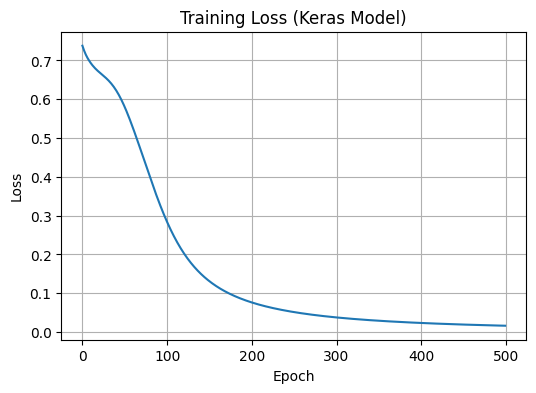

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss (Keras Model)')
plt.grid(True)
plt.show()


**Observation:** The graph shows the Binary Cross-Entropy loss decreasing as training progresses. A steadily decreasing curve that flattens out near the end indicates that the model is successfully learning the XOR pattern and converging to a good solution.

# Task 4 — TensorFlow Low-Level API

## Keras vs TensorFlow Low-Level API

**Keras:** A high-level API that makes building neural networks easy using ready-made layers (like `Dense`) and models (like `Sequential`). We don't need to manually manage weights or gradients.

**TensorFlow Low-Level API:** Gives us direct control over tensors, weights, the forward pass, and gradient updates. We manually create the weight variables, write the forward-pass equations, compute the loss, and use `tf.GradientTape()` to calculate and apply gradients ourselves.

Below, we re-implement the same XOR problem using only low-level TensorFlow operations, without using any Keras layers.

## Build and Train the TensorFlow Model

We manually create the weights and biases for a hidden layer (2 inputs to 4 hidden neurons, Tanh activation) and an output layer (4 hidden neurons to 1 output, Sigmoid activation). We then write a forward-pass function, compute Binary Cross-Entropy loss, and train using `tf.GradientTape()` with the Adam optimizer.

In [11]:
tf.random.set_seed(42)

n_hidden = 4

# Weights and biases as TensorFlow Variables
W1 = tf.Variable(tf.random.normal([2, n_hidden], stddev=1.0, seed=42))
b1 = tf.Variable(tf.zeros([n_hidden]))
W2 = tf.Variable(tf.random.normal([n_hidden, 1], stddev=1.0, seed=42))
b2 = tf.Variable(tf.zeros([1]))

X_tf = tf.constant(X, dtype=tf.float32)
y_tf = tf.constant(y, dtype=tf.float32)

def forward_pass(inputs):
    hidden = tf.tanh(tf.matmul(inputs, W1) + b1)
    output = tf.sigmoid(tf.matmul(hidden, W2) + b2)
    return output

def compute_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()
    return bce(y_true, y_pred)

tf_optimizer = tf.keras.optimizers.Adam(learning_rate=0.05)

epochs_tf = 1000
tf_loss_history = []

for epoch in range(epochs_tf):
    with tf.GradientTape() as tape:
        y_pred = forward_pass(X_tf)
        loss = compute_loss(y_tf, y_pred)

    gradients = tape.gradient(loss, [W1, b1, W2, b2])
    tf_optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2]))
    tf_loss_history.append(loss.numpy())

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {loss.numpy():.4f}")

print(f"\nFinal Loss: {tf_loss_history[-1]:.4f}")


Epoch 0: Loss = 0.7505
Epoch 100: Loss = 0.0168
Epoch 200: Loss = 0.0048
Epoch 300: Loss = 0.0024
Epoch 400: Loss = 0.0015
Epoch 500: Loss = 0.0011
Epoch 600: Loss = 0.0008
Epoch 700: Loss = 0.0006
Epoch 800: Loss = 0.0005
Epoch 900: Loss = 0.0004

Final Loss: 0.0003


## TensorFlow XOR Predictions

We use the trained low-level TensorFlow model to predict all four XOR combinations, convert probabilities to 0/1 predictions with a threshold of 0.5, and calculate accuracy.

In [12]:
tf_probs = forward_pass(X_tf).numpy()
tf_preds = (tf_probs > 0.5).astype(int)

tf_results_df = pd.DataFrame({
    "Input 1": X[:, 0].astype(int),
    "Input 2": X[:, 1].astype(int),
    "Actual Output": y.flatten().astype(int),
    "Predicted Probability": tf_probs.flatten(),
    "Predicted Output": tf_preds.flatten()
})
print(tf_results_df)

tf_accuracy = (tf_preds.flatten() == y.flatten()).mean()
print(f"\nTensorFlow Low-Level Model Accuracy: {tf_accuracy * 100:.2f}%")


   Input 1  Input 2  Actual Output  Predicted Probability  Predicted Output
0        0        0              0               0.000290                 0
1        0        1              1               0.999515                 1
2        1        0              1               0.999950                 1
3        1        1              0               0.000539                 0

TensorFlow Low-Level Model Accuracy: 100.00%


**Observation:** Just like the Keras model, the TensorFlow low-level implementation predicts probabilities for all 4 XOR inputs. Comparing the "Actual Output" and "Predicted Output" columns shows whether this manually built model also learned the non-linear XOR pattern correctly.

# Task 5 — Comparison

## Keras vs TensorFlow Low-Level API

| Feature | Keras | TensorFlow Low-Level |
|---|---|---|
| Ease of implementation | Very easy, ready-made layers | Harder, everything written manually |
| Amount of code | Very little code | More code needed |
| Control over calculations | Limited, hidden inside layers | Full control over every step |
| Ease of training | `model.fit()` handles everything | Manual training loop with GradientTape |
| Suitable for beginners | Yes, beginner-friendly | Better once basics are understood |

Below we compare the actual final accuracy obtained by both implementations.

In [13]:
comparison_df = pd.DataFrame({
    "Implementation": ["Keras", "TensorFlow Low-Level"],
    "Final Accuracy": [keras_accuracy, tf_accuracy]
})
print(comparison_df)


         Implementation  Final Accuracy
0                 Keras             1.0
1  TensorFlow Low-Level             1.0


**Explanation:** Both implementations solve the exact same XOR problem, but Keras hides most of the implementation details (weights, forward pass, gradient updates) behind simple methods like `model.fit()`, while the TensorFlow low-level version requires us to write and manage all of these steps ourselves. The accuracy values above are the actual results calculated from each model's predictions on the XOR dataset.

# Conclusion

In this lab, we learned that XOR is a non-linear Boolean function that a simple linear model (a single perceptron) cannot learn correctly, since its outputs are not linearly separable. By adding a hidden layer with a non-linear activation function, an MLP is able to learn XOR successfully.

We used Binary Cross-Entropy as the loss function, which is well suited for binary classification problems like this one. We also observed how hyperparameters such as the number of neurons, learning rate, and number of epochs affect how well and how quickly the model learns.

Finally, we implemented XOR using both Keras and the TensorFlow low-level API. Keras made the implementation much simpler using ready-made layers and the `fit()` method, while the TensorFlow low-level API gave us more direct control over the weights, forward pass, and gradient updates, at the cost of writing more code. Both approaches were able to successfully learn the XOR function.